# <u>Intro to statistics - part 1: sample statistics, distributions </u>


## What will you learn from this notebook?

- Dealing with random variables, computing basic sample statistics
- Learn some basic properties of random samples
- Basic information and properties of continuous probability distributions
- Fitting a parametric probability distribution and evaluating the quality of the fit



# 1.1 Dataset description and sample import

### Dataset 1: synthetic wind speed data
The text file *'SyntheticWind.txt'* contains numerically generated wind time series. The file contains a single column of data which represents the instantaneous wind speed. The time step is $\Delta_t = 0.1s$, meaning the sampling frequency is 10Hz. There are a total of 12,000 data points equal to 20 minutes of data. The file can easily be read using the `numpy.loadtxt` command. Run the cell below to load the data and display a simple plot.

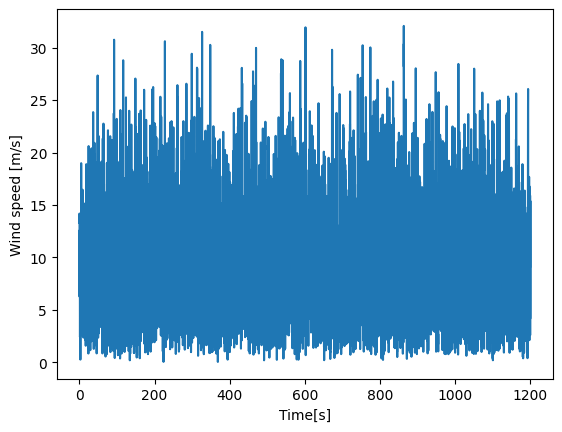

In [2]:
# Data import and basic plot of the time series
import numpy as np
X = np.loadtxt('SyntheticWind.txt')
import matplotlib.pyplot as plt
plt.plot(np.arange(len(X))/10,X)
plt.xlabel('Time[s]')
plt.ylabel('Wind speed [m/s]')
plt.show()

In the above, the wind speed is a ***random variable*** defined on a continuous scale. A random variable can be described by its probability distribution - which defines how likely it is that the variable attains a given value. 

What is $\mathbf{X}$ in the code cell above? 

$\mathbf{X}$ is a ***sample*** from the random variable (wind speed). A sample is a finite set of values drawn from a population. 







# 1.2. Probability distributions

Probability distributions are a way to describe random variables. A probability distribution defines how likely it is that the variable attains a given value. Below, we introduce a few essential properties of probability distributions.

### Probability density function
A continuous, real-valued random variable $X$ has a probability density function $f(x)$ at value $x$ if 

$P[a \leq X \leq b] = \int_{a}^{b}{f(x)dx}                \quad \quad           (1)$  


In practical terms, the probability density function (pdf) can thus be considered as a measure of the probability of $X$ falling within an infinitesimal interval $[x, x + \Delta x]$.

### Cumulative distribution function
The cumulative distribution function (cdf) of a random variable $X$ at point $x$ represents the probability that the value of $X$ will be less than or equal to $x$:

$F(x) = P(X \geq x)$

The value of $F(x)$ is given by the integral of the probability density function:

$F(x) = \int_{-\infty}^{x}{f(x)dx}$

As it is a measure of probability, the interval of definition of $F(x)$ is $0 \leq F(x) \leq 1$.
From the definition of the pdf and cdf functions it follows that the probability density function is the derivative of the cumulative distribution function:

$f(x) = \frac{d}{dx}F(x)$

Furthermore, equation (1) can also be expressed in terms of the cdf:

$P[a \leq X \leq b] = \int_{a}^{b}{f(x)dx} = F(b) - F(a)$

The complementary function of the cdf:

$P(x) = P(X \geq x) = 1 - F(x)$

represents the probability of exceeding a given threshold value of $x$, and is usually referred to as exceedance probability or simply exceedance. The exceedance probability is a useful measure of the probabilities in the upper tail of a distribution, e.g., in modelling cases such as extreme loads on structures, extreme winds, etc.

### Parametric probability distributions

A convenient way of carrying out computations on random variables and their probabilities is by defining their PDF and CDF in terms of continuous functions with a few common parameters. This is a ***parametric probability distribution***. Some common examples of parametric distributions that are frequently used in wind applications include:

- Normal (Gaussian) distribution
- Weibull distribution
- Lognormal distribution

We have a more detailed description of these distribution types in the slides.

Given the parametric distribution formulas, we can compute and visualize distributions in Python. A common library for dealing with probability distributions is *scipy.stats*. Let us visualize a few distribution examples using scipy below. 

### **Coding Task 1.2**: 
- Create a Python plot with two subplots. In the first subplot, show the PDF of a Gaussian distribution with mean of 10 and standard deviation of 5, for a variable value range of [-5,25]. On the second subplot, plot the CDF of the same distribution. 

Once you're done with the Gaussian distribution plot, you may add the following distributions:
- A Weibull distribution with scale parameter A = 10 and shape parameter k = 2 (this is given as "c" in scipy). The Weibull distribution is defined in scipy as "weibull_min"
- A Lognormal distribution with mean of $\mu_X = 10$ and standard deviation of $\sigma_X = 5$. This distribution would be defined with a scale parameter $\mu = \ln \frac{\mu_X^2}{\sqrt{\mu_X^2 + \sigma_X^2}}$ (defined as *scale* = $\exp (\mu)$ in scipy) and a shape parameter $\sigma = \sqrt{\ln( 1 + \frac{\sigma_X^2}{\mu_X^2} )} $ (defined as *s* in scipy).

Text(0, 0.5, 'CDF')

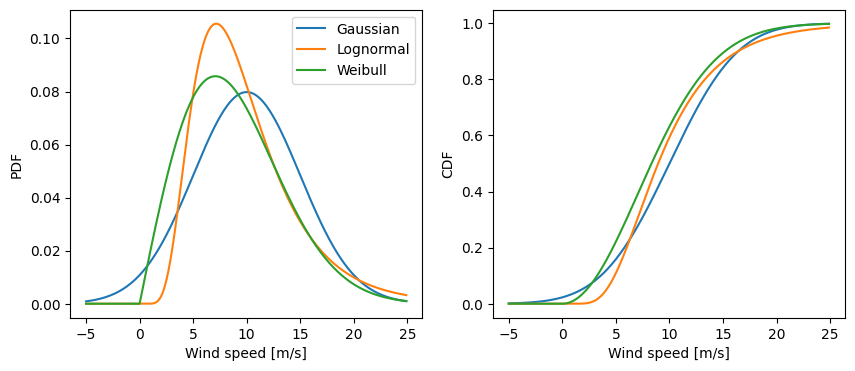

In [16]:
import scipy.stats as stats

fig1, ax1 = plt.subplots(1,2,figsize = (10,4))

X = np.arange(-5,25,0.1)

pdfX_Gaussian = stats.norm.pdf(X, loc = 10, scale = 5)
cdfX_Gaussian = stats.norm.cdf(X, loc = 10, scale = 5)

pdfX_Lognorm = stats.lognorm.pdf(X, scale = ((10**2)/np.sqrt(10**2 + 5**2)), s = np.sqrt(np.log(1 + (5**2)/(10**2))))
cdfX_Lognorm = stats.lognorm.cdf(X, scale = ((10**2)/np.sqrt(10**2 + 5**2)), s = np.sqrt(np.log(1 + (5**2)/(10**2))))

pdfX_Weibull = stats.weibull_min.pdf(X, c = 2, scale = 10, loc = 0)
cdfX_Weibull = stats.weibull_min.cdf(X, c = 2, scale = 10, loc = 0)

ax1[0].plot(X,pdfX_Gaussian)
ax1[1].plot(X,cdfX_Gaussian)

ax1[0].plot(X,pdfX_Lognorm)
ax1[1].plot(X,cdfX_Lognorm)

ax1[0].plot(X,pdfX_Weibull)
ax1[1].plot(X,cdfX_Weibull)

# Add labels and legends
ax1[0].set_xlabel('Wind speed [m/s]')
ax1[0].set_ylabel('PDF')
ax1[0].legend(['Gaussian','Lognormal','Weibull'])
ax1[1].set_xlabel('Wind speed [m/s]')
ax1[1].set_ylabel('CDF')

# Loc:   The mean of the distribution. 
#        - It describes around which point the fucntion is centered in the distribution. 


# Scale: The standard deviation of the distribution. 
#        - It describes how spread out the distribution is. 
#        - Larger scale value means that the distribution is more spread out, while 
#        - Smaller scale value means that it is more concentrated around the mean.


# 1.3. Moments of probability distributions
The $n-th$ moment of a real-valued continuous function $f(x)$ at point $c$ is given by

$\mu'_n = \int_{-\infty}^{\infty}{(x-c)^n f(x) dx}$

When $f(x)$ is a probability density function, the values of $\mu'_n$ represent the moments of a statistical distribution. 
The moments are usually evaluated for $c = 0$, and these values are referred to as raw moments. The $n-th$ raw moment equals the expected value of $X^n$. The moments about the mean, i.e., $c = E[X]$, are called central moments. Furthermore, when the $n-th$ central moment is normalized by dividing with $\sigma^n$, it is called a standardized moment. 

Moments are important characteristics of the statistical distributions providing information about the shape and location of the probability density and distribution functions. The first four moments are usually referred to by their specific names:

- The first __raw__ moment is the mean of the distribution
- The second __central__ moment is the variance
- The third  __standardized__ moment is called skewness
- The fourth __standardized__ moment is called kurtosis

Many of the regularly used named statistical distributions can be completely defined by the first few of their moments, e.g., Normal and Lognormal distributions (first two moments), Weibull distribution (first three moments), etc.

The Normal distribution has a skewness of 0 and kurtosis of 3. Often, instead of the kurtosis, the so-called excess kurtosis is used, which equals the kurtosis minus 3, thus defining the kurtosis of a Normal distribution as a reference.

### **Coding task 1.3:**

On a single axis, plot the probability density function (pdf) of three Weibull distributions: 
1) With A (scale) parameter = 12 and shape (k) parameter = 3
2) With A (scale) parameter = 7 and shape (k) parameter = 2
3) With A (scale) parameter = 12 and shape (k) parameter = 5

Which of the three distributions has the highest standard deviation (second moment)? And what can you say about the skewness of the three distributions?


Mean of Weibull distribution with c = 3: 10.72
Mean of Weibull distribution with c = 2: 6.20
Mean of Weibull distribution with c = 5: 11.02
Standard deviation of Weibull distribution with c = 3: 3.89
Standard deviation of Weibull distribution with c = 2: 3.24
Standard deviation of Weibull distribution with c = 5: 2.52


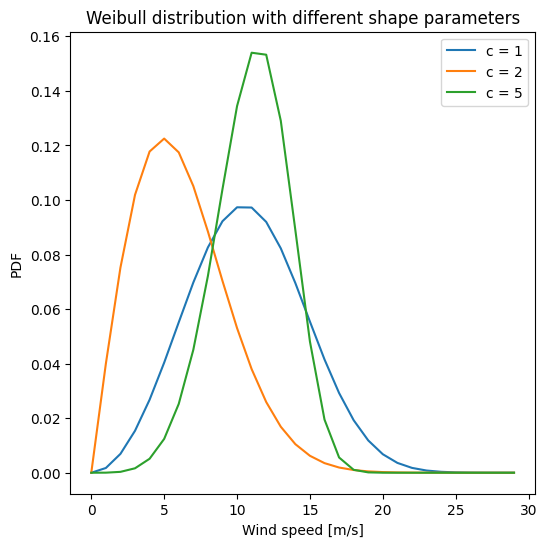

In [27]:
# CODE FOR TASK 1.3
fig2, ax2 = plt.subplots(1,1,figsize = (6,6))
x2 = np.arange(0,30)

ax2.plot(x2,stats.weibull_min.pdf(x2, c = 3, scale = 12, loc = 0))
ax2.plot(x2,stats.weibull_min.pdf(x2, c = 2, scale = 7, loc = 0))
ax2.plot(x2,stats.weibull_min.pdf(x2, c = 5, scale = 12, loc = 0))

ax2.set_xlabel('Wind speed [m/s]')
ax2.set_ylabel('PDF')
ax2.set_title('Weibull distribution with different shape parameters')
ax2.legend(['c = 1','c = 2','c = 5'])


# Get mean of the different Weibull distributions
mean_k3 = stats.weibull_min.mean(c = 3, scale = 12, loc = 0)
mean_k2 = stats.weibull_min.mean(c = 2, scale = 7, loc = 0)
mean_k5 = stats.weibull_min.mean(c = 5, scale = 12, loc = 0)

for c, mean in zip([3, 2, 5], [mean_k3, mean_k2, mean_k5]):
    print(f'Mean of Weibull distribution with c = {c}: {mean:.2f}')


# Get the standard deviation of the different Weibull distributions
std_k3 = stats.weibull_min.std(c = 3, scale = 12, loc = 0)
std_k2 = stats.weibull_min.std(c = 2, scale = 7, loc = 0)
std_k5 = stats.weibull_min.std(c = 5, scale = 12, loc = 0)

for c, std in zip([3, 2, 5], [std_k3, std_k2, std_k5]):
    print(f'Standard deviation of Weibull distribution with c = {c}: {std:.2f}')


# 1.4. Sample statistics

## **Quiz** - conceptual example with number of babies
A town is served by two hospitals. In the larger about 45 babies are born each day, in the smaller about 15. For a period of 1 year, each hospital recorded the days on which more than 60 percent of the babies born were boys.

Quiz: which hospital do you think recorded more such days?

    A) The larger hospital
    B) The smaller hospital
    C) About the same (that is, within 5 percent of each other)

Please suggest an answer - we will reveal the true answer later. 


### Simplified version of the "quiz": 

We draw one sample from a random variable. Are the sample statistics and distribution the same as those of the random variable being sampled? 

    A) Yes
    B) No
    C) It depends

In the next few cells of code, we will do some sampling tests that will hopefully give us a clue about the answer.



### **Coding task 1.4:**
We have seen how to draw parametric distributions. There are also functions that generate random samples following prescribed probability distributions. For example, one can use *stats.[distribution].rvs()*. Let us: 
1) Draw ten samples of size 100 from a Normal (Gaussian) distribution with mean of 10 and standard deviation of 3. For each sample, compute its mean and standard deviation, and store it in an array. 
2) What kind of numbers do we get? Are they the same each time? What if we changed the sample size, or the number of times we draw the sample? 
3) Now, let's try with another distribution. Do we see the same results?

Means = [10.19797836  9.86983489  9.27594451  9.74068855 10.57771262 10.18652875
  9.89412693  9.87479985 10.22073492 10.53038097]


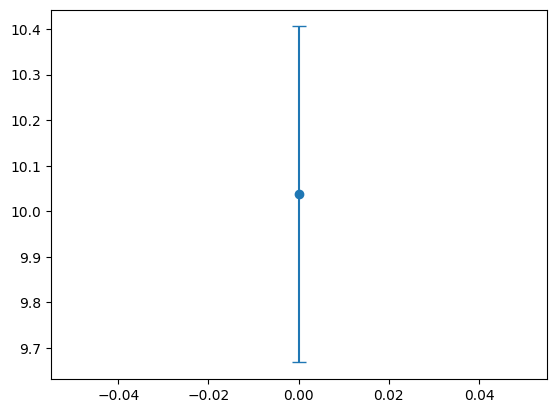

In [7]:
# Coding task 1.4:
# Test 1 - ten samples of same size. 

Nsamples = 10
Sample_size = 100
Means = np.zeros(Nsamples)
Stds = np.zeros(Nsamples)

for i in range(Nsamples):
    Xi = stats.norm.rvs(size = Sample_size, loc = 10, scale = 3)
    Means[i] = np.mean(Xi)
    Stds[i] = np.std(Xi)


plt.errorbar(0,np.mean(Means), np.std(Means), marker = 'o', capsize = 5)
print('Means = ' + str(Means))

In [ ]:
# Coding task 1.4:
# Test 2 - different sample sizes and number of times we draw the samples

Nsamples = 10
Sample_sizes = [10,100,1000]
Ensemble_Means = np.zeros(len(Sample_sizes))
Ensemble_Stds = np.zeros(len(Sample_sizes))

for j in range(len(Sample_sizes)):
    Means = np.zeros(Nsamples)

    for i in range(Nsamples):
        Xi = stats.norm.rvs(size = Sample_sizes[j], loc = 10, scale = 3)
        Means[i] = np.mean(Xi)
    
    Ensemble_Means[j] = np.mean(Means)
    Ensemble_Stds[j] = np.std(Means)


plt.errorbar(np.log10(Sample_sizes),Ensemble_Means, Ensemble_Stds, marker = 'o', capsize = 5)
print('Ensemble stds = ' + str(Ensemble_Stds))

Ensemble stds = [0. 0. 0.]


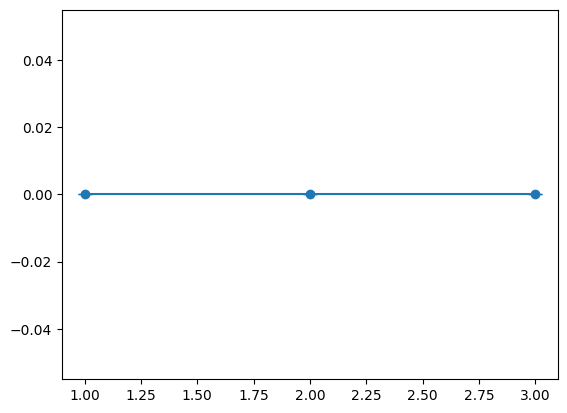

In [8]:
# Coding task 1.4:
# Test 3 - different sample sizes and number of times we draw the samples
# EXAMPLE WITH WEIBULL-DISTRIBUTED DATA

Nsamples = 100
Sample_sizes = [10,100,1000]
Ensemble_Means = np.zeros(len(Sample_sizes))
Ensemble_Stds = np.zeros(len(Sample_sizes))

# YOUR CODE STARTS HERE


# YOUR CODE ENDS HERE


plt.errorbar(np.log10(Sample_sizes),Ensemble_Means, Ensemble_Stds, marker = 'o', capsize = 5)
print('Ensemble stds = ' + str(Ensemble_Stds))

### Quiz re-evaluation:

Can you think again about the quiz discussing number of babies? Based on the above exercises, has your answer choice changed - or reinforced?

# 1.5. More on samples and their basic statistical properties
In statistics, a sample is a finite subset of a statistical population, which has been collected by a defined procedure (e.g. a measurement campaign or a simulation). Theoretically, when the sample size tends to infinity the statistical properties of the sample should converge to the properties of the parent population. However, if we draw multiple __finite-size__ random samples of the same population, the properties of the different samples will differ from each other. The uncertainty in the properties of the random samples and whether they are trully representative of the population properties is the so-called statistical uncertainty and is a common phenomenon when working with measured or simulated data sets. The statistical uncertainty typically decreases with increasing sample size. 

For a given sample, we can obtain empirical estimates of the statistical properties such as moments and distriubution functions, by employing discretized versions of the formulas for pdf, cdf and statistical moments given earlier. 

The sample mean is found by

$\bar{x} = \frac{1}{n}\sum_{i=1}^n{x_i}$

Sample variance:

$\sigma^2 = \frac{1}{n-1}\sum_{i=1}^n{(x_i - \bar{x})^2}$

Coefficient of variation: 
$c.o.v = \frac{\sigma}{x}$

A simple way to define an empirical cdf of the data sample consists of the following steps:

1) Given a sample of size $n$, sort the data in ascending order, giving the sorted data points ranks from 1 to $n$

2) For a data point with rank $k$, $k = 1\ldots n$, the empirical cdf is found by

$F_k = \frac{k}{n+1}$

The expression $k/(n+1)$ means that the observed quantiles are assumed to be uniformly distributed between 0 and 1, which will asymptotically be the correct behaviour (i.e., it is useful for large samples).

Theoretically, the pdf (probability density function) can be obtained from the cdf using differentiation. Would it  work if we tried to compute the sample pdf by differentiating the sample cdf?

As an alternative, the probability density function can be estimated from data by assembling a histogram and using the condition that the integral of the pdf over the entire range of the variable should be equal to 1. 



## Coding task 1.5: expanding on basic sample statistics
The goal with this task is to study sample statistics - exercise the methods for evaluating them, and see some specific properties and caveats of the sample statistics. Please do the following:

- Use dataset 1. It can be loaded using `numpy.loadtxt` as shown earlier.
- What are the mean, standard deviation, skewness and kurtosis (the first 4 statistical moments) of the data? Do the in-built functions in the Python libraries provide exactly the expected result?
- Can you plot a histogram of the data? Try using different fractions of the dataset (e.g., 100 points, 1000 points, 10000 points). What is the effect of using different amounts of data on the way the histogram looks?
- Try to split the data in multiple, smaller datasets of equal length (e.g. 10, 50, 100, 1000 points in each dataset). Take the mean of each sub-dataset. In this way you will obtain a number of different means - e.g. if you split the 12,000 datapoints into 120 datasets of 100 points each, you can obtain 120 mean values. What is the standard deviation of this "sample of means" - and how does it change according to the length of the sub-datasets?

### Cheat sheet for Task 1.5
- You will need the numpy library in order to process numeric datasets efficiently. You can load it as `import numpy as np`.

- Data from text files in ascii format can be easily loaded using `np.loadtxt`.

- The `scipy.stats` module contains functions for evaluating the skewness and curtosis of a sample:

    `import scipy.stats as stats
    skewness = stats.skew(x)
    kurtosis = stats.kurtosis(x)`
    
- For a 1-D array where the total number of elements is a multiple of the size of the sub-arrays one wants to divide it to, the division can be easily carried out with the `reshape` command. Then the mean or other operations could be done for each row or column of the array by using the `axis` option in the command, e.g. `MeanY = Y.reshape((n_rows,n_columns)).mean(axis=1)` will result in an array of mean values with size `n_rows`. 


### Code for Task 1.5

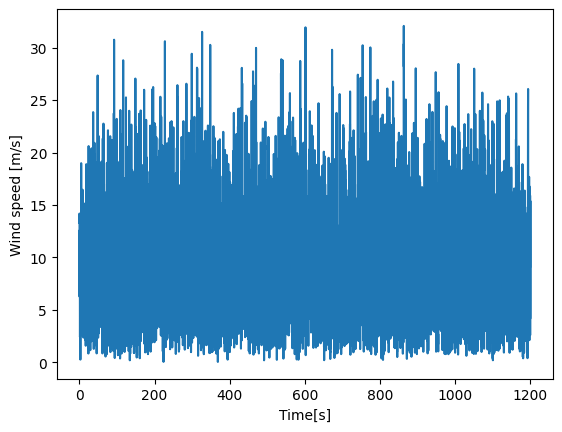

In [9]:
# DATA ALREADY IMPORTED IN EARLIER CELL - RUN AGAIN HERE TO GET THE RIGHT VARIABLES RELOADED
# Data import and basic plot of the time series
#import numpy as np
X = np.loadtxt('SyntheticWind.txt')
#import matplotlib.pyplot as plt
plt.plot(np.arange(len(X))/10,X)
plt.xlabel('Time[s]')
plt.ylabel('Wind speed [m/s]')
plt.show()

In [ ]:
# Mean, standard deviation, skewness, kurtosis

M1 = np.mean(X)# Mean using an in-built Python function
M2 = np.sum(X)/len(X)# Mean using the formula given in the slides/notebook

S1 = np.std(X, ddof = 1)# Standard deviation using an in-built Python function
S2 = np.sqrt((1/(len(X)-1))*np.sum((X - np.mean(X))**2))# Standard deviation using the formula given in the slides/notebook

import scipy.stats as stats
Skew = 
Kurt = 

print('Numpy mean: ' + str(M1))
print('Mean by formula: ' + str(M2))
print('Numpy std: ' + str(S1))
print('Std by formula: ' + str(S2))
print('Skewness: ' + str(Skew))
print('Kurtosis: ' + str(Kurt))


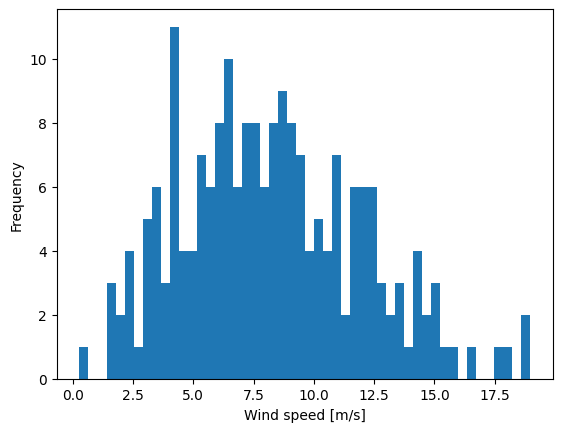

In [10]:
# PLOT THE HISTOGRAM OF THE DATA
phist = plt.hist(X[:200],50) # Change the second number to study the effect of bin widths
plt.xlabel('Wind speed [m/s]')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Histogram - storing the numbers

Hist = np.histogram(X,50)
Xcounts = Hist[0]
Xbinedges = Hist[1]
Binwidths = np.diff(Xbinedges)

fig1 = plt.figure()
axs1 = fig1.add_subplot()
axs1.bar(Xbinedges[:-1],Xcounts,width = Binwidths,align = 'edge')
axs1.set_xlabel('Wind speed [m/s]')
axs1.set_ylabel('Count')
plt.show()

In [ ]:
# Data splits
N = [5,10,50,100,500,1000]

# Doing it in the most detailed way in order to show the separate steps:
Stdevs = np.zeros(len(N))
for i in range(len(N)):
    Xi = np.reshape(X,(int(N[i]),int(len(X)/N[i])))
    Meansi = np.mean(Xi,axis=0)
    Stdevs[i] = np.std(Meansi)
    print('N = ' + str(N[i]) + ', shape of Xi:' + str(Xi.shape))
    print('N = ' + str(N[i]) + ', shape of Meansi:' + str(Meansi.shape))

# Doing it with a for-loop, all operations lumped in one line:
#Stdevs = np.zeros(len(N))
#for i in range(len(N)):
#    Stdevs[i] = X.reshape((int(N[i]),int(len(X)/N[i]))).mean(axis=0).std()

# Doing it with "list comprehension" - repeat the operation for each element in list
#Stdevs = [X.reshape((Ni,int(len(X)/Ni))).mean(axis=0).std() for Ni in N ]

TheoreticalStdevs = np.std(X)/np.sqrt(N)

print('Theoretical standard deviations: ' + str(TheoreticalStdevs))

plt.plot(N,TheoreticalStdevs,'-b')
plt.plot(N,Stdevs,'*k',markersize = 5)
plt.show()


# 1.6. Computing empirical PDF and CDF

### Computing a cumulative distribution function (CDF) empirically
By calling the PDF and CDF *empirical*, we mean computing these statistical quantities directly from observations (data), without taking assumptions about distribution family or parameters. 
The empirical cumulative distribution function of a data sample can be obtained by ranking the realizations $y_i = f(x_i)$, $i = 1,...,n$ according to their values:

$F_k = \frac{k}{(n + 1)}$

where $y_{k+1} >= y_{k} >= y_{k-1},...$, and the result $F_k$ is the cumulative distribution function value of a point with rank $k$, and $n$ is the total number of data points in a sample. The expression $k/(n+1)$ means that the observed quantities are assumed to be uniformly distributed between 0 and 1, which will asymptotically be the correct behaviour (i.e., useful for large samples). The denominator value $n+1$ is chosen so that the last point in the sequence (when $k = n$) is always less than 1, meaning that there is no artificially imposed upper bound of the distribution at $y_n$. 


### **Coding task 1.6.1:** Computing an empirical CDF 

Can you compute and plot the empirical CDF of *'SyntheticWind.txt'*?

In order to plot the sample (empirical) cdf based on the formula defined above, we have to start with sorting the data. This is done with the _np.sort()_ function where the default behaviour is sorting in ascending order. Defining the data point ranks can be done by creating a numpy array of integers using the function _np.arange()_.

In [ ]:
# Code for Task 1.6:

X = np.loadtxt('SyntheticWind.txt')
Xsort = np.sort(X)
Fx = np.arange(1, len(Xsort) + 1) / (len(Xsort) + 1)

### Computing a probability density function (pdf) empirically

Let us take an overview of the data by plotting a histogram (for example - using the plt.histogram function as shown in the cell below)

The histogram shown below looks a lot like a probability density function (pdf), but it does not exactly correspond to a pdf. What is the main difference?

The correct answer is: the y-axis, the scale given by the histogram is just number of counts and depends on the sample size. In order to turn a histogram into a probability density function, we can use a key property of the pdf, which is:

$\int_{-\infty}^{\infty}f(x)dx = 1$

Using the above property, an empirical pdf can be obtained from a data sample with the following steps:

1) Split the data into equally-sized bins, and count the occurrences in each bin (i.e., make a histogram)
2) Compute the definite integral of the histogram counts with respect to the bins, using a numerical integration procedure
3) Normalize the histogram counts by dividing with the integral from point 2)

The empirical pdf from the data is represented by the normalized histogram counts, and is defined at the bin centers. 

In [ ]:
# Histogram of the data
fig3 = plt.figure()
axs3 = plt.gca()
hist1 = axs3.hist(X,50)
plt.xlabel('Wind speed [m/s]')
plt.ylabel('Number of occurrences')
plt.show()

### **Coding task 1.6.2:** compute an empirical pdf

Please compute the empirical pdf from the same dataset we have used in the notebook until now - by making a histogram and normalizing with a numerically computed integral.

As a help: 
- We have defined a simple integration function - "rectangle rule". Note that the rule requires computing distance between bin edges - hence the number of points (edges) in x is one more than the counts (y).
- In order to get the histogram as an array rather than a plot, you can use the *np.histogram* command


Try different number of bins. Do you see any difference?

In [ ]:
# SIMPLE INTEGRATION FUNCTION
def rectangle_rule(x,y):
    res = np.sum(np.diff(x[0:y.shape[0]+1])*y)
    return res

In [ ]:
# NUMERICAL PDF COMPUTATION

Xhist = np.histogram(X,bins = 30)
Xcounts = Xhist[0]
Xbins = Xhist[1]

# INSERT YOUR CODE HERE
Xintegral = 
Xpdf = 
# END YOUR CODE HERE

In [ ]:
# PLOT NUMERICAL PDF

Xbinsc = Xbins[:-1] + np.diff(Xbins)/2 # Find the bin centers for plotting (histogram is based on bin edges!)
plt.plot(Xbinsc,Xpdf)
plt.xlabel('Mean wind speed [m/s]')
plt.ylabel('Probability density')
plt.show()

There are also readily available functions in the scipy package which can help you compute an empirical cdf and pdf. In the example below, we do that in two steps: 1) define a custom probability distribution object from the data, and 2) compute the pdf or cdf with the respective methods.

In [ ]:
Xdist_emp = stats.rv_histogram(Xhist)
fig4,ax4 = plt.subplots(1,2,figsize = (10,5))
ax4[0].plot(Xbinsc,Xpdf)
ax4[0].plot(Xbinsc,Xdist_emp.pdf(Xbinsc),'--r')
ax4[0].set_xlabel('Mean wind speed [m/s]')
ax4[0].set_ylabel('Probability density')
ax4[1].plot(Xsort,Fx)
ax4[1].plot(Xsort,Xdist_emp.cdf(Xsort),'--r')
ax4[1].set_xlabel('Mean wind speed [m/s]')
ax4[1].set_ylabel('Cumulative distribution function')
plt.show()



# 1.7. Distribution fitting 

### The max-likelihood method
The Maximum-Likelihood Estimate (MLE) is one of the most widely used methods for fitting statistical distributions and probabilistic models in general. For a given set of function parameters $\boldsymbol{\theta}$ (e.g., the parameters of a probability distribution), the likelihood $\mathcal{L}$ represents a measure of the possibility that a given set of observations (i.e., a sample) $\mathbf{x}$ belongs to the population of function values $f_{\boldsymbol{\theta}}(\mathbf{x})$. In mathematical language, this description may be written as

$\mathcal{L}(\boldsymbol{\theta}\vert \mathbf{x}) = P(\mathbf{x}\vert\boldsymbol{\theta})$

For a statistical distribution, the likelihood is given in terms of the probability density function:

$\mathcal{L}(\boldsymbol{\theta}\vert \mathbf{x}) = \prod_{i = 1}^{n}f(x_i \vert \boldsymbol{\theta})$

where $\mathbf{x} = [x_1,x_2, \ldots , x_n]$ is a set of observations, and $f(x_i \vert \boldsymbol{\theta})$ is the probability density of an observation $x_i$ given distribution parameters $\boldsymbol{\theta}$. 
As the values of the pdf function are often marginal (i.e., very close to zero), using the product representation in the equation above can lead to numerical problems. Therefore, the more widely used representation is the natural logarithm of the likelihood function, the log-likelihood (sometimes also referred as simply the likelihood):

$\log \mathcal{L}(\boldsymbol{\theta}\vert \mathbf{x}) = \sum_{i = 1}^{n}\log(f(x_i \vert \boldsymbol{\theta}))$

The likelihood function is not a direct measure of probability, and a single value of the function does not convey any specific information. However, the point at which the likelihood attains its maximum indicates the best fit between the observations and the suggested function. Based on this property, the maximum likelihood estimator for the model parameters $\boldsymbol{\theta}$ is given as

$\boldsymbol{\theta}_{mle} = \arg\min \left(-\log\mathcal{L}(\boldsymbol{\theta}\vert \mathbf{x})\right)$

The formula above represents the typical form of the Maximum Likelihood method, where for a continuous likelihood function the negative log-likelihood function is minimized using an optimization algorithm. 

### The method of moments
Many distributions have closed-form expressions relating their statistical moments (e.g. mean and variance) to their distribution parameters. Thus, assuming that a random sample follows a given statistical distribution, the distribution parameters can be estimated from the sample statistics. For example, for a Weibull-distributed variable the following relations exist between the mean $\mu$, variance $\sigma^2$, and the distribution parameters $A$ and $k$:

$\mu = A\Gamma(1 + 1/k)$  ;  $ \sigma^2 = A^2 \left[\Gamma(1 + 2/k) - (\Gamma(1 + 1/k))^2\right]$

where $\Gamma()$ is the Gamma function.

For a given pair of values $(\mu, \sigma)$, the Weibull parameters $A$ and $k$ can be estimated from the above equation by 1) defining an expression for $A$ from the first equation, 2) substituting $A$ in the second equation, and 3) solving the second equation for $k$ iteratively.


## **Coding Task 1.7** - probability distribution fitting
We are given the file "Windspeed_Sample_1.txt" which contains 10-minute mean wind speed measurements at the Høvsøre wind turbine test site over several years. Your tasks are the following:

1) (Repetition from earlier task with new data set): Evaluate the sample statistics: mean, variance, skewness, curtosis, minimum, maximum value. Could you think of how the probability distribution of the data should look like, based on these statistics?

2) (Repetition from earlier tasks with new data set): Make a computer program that calculates and plots the empirical cdf and pdf of the 10-minute average wind speed.

3) Fit a Weibull distribution to the data using

- The method of moments
- The max-likelihood method    

Are there any differences in the results? Why?

4) Now try to fit other distributions, e.g. Normal, Lognormal or Gumbel distribution, using the max-likelihood method. Are the fits successful? Show it using Q-Q plots and K-S tests.

### Code for Task 1.7 (hints between the code cells)

In [1]:
# Initialize libraries
import numpy as np # THE most used Python library for basic mathematical computing with numerical arrays
import matplotlib.pyplot as plt # A library for plotting functions

In [3]:
# Load data. Here we use a very basic approach - later in the course we may need more advanced ones.
U = np.loadtxt('data/Windspeed_Sample_1.txt')

# Show the shape of the loaded data array U:
print('Number of samples:' + str(U.shape))

Number of samples:(158693,)


Below, we plot the data time series. What tells us that this is a time series?

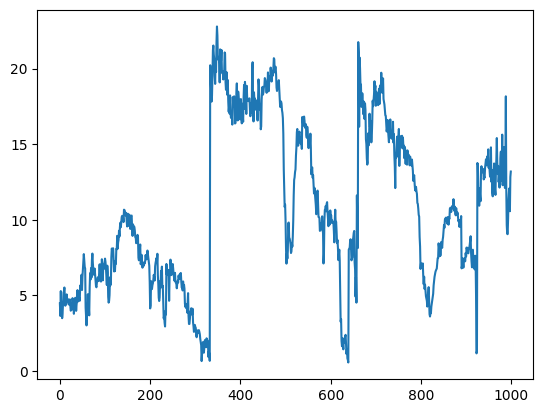

In [4]:
plt.plot(U[:1000])
plt.show()

Just as in the earlier example, let us get an overview of the data stats:

In [5]:
# CODE FOR COMPUTING MEAN, STANDARD DEVIATION, SKEWNESS AND KURTOSIS

import scipy.stats as stats

Umean = np.mean(U)
Uvar = np.var(U)
Uskew = stats.skew(U)
Ukurt = stats.kurtosis(U)

print('Wind speed stats: ')
print('mean = ' + str(Umean))
print('std.dev = ' + str(np.sqrt(Uvar)))
print('skewness = ' + str(Uskew))
print('kurtosis = ' + str(Ukurt))

Wind speed stats: 
mean = 9.45992246980018
std.dev = 4.853742908469193
skewness = 0.6116343746493218
kurtosis = 0.3903390563510136


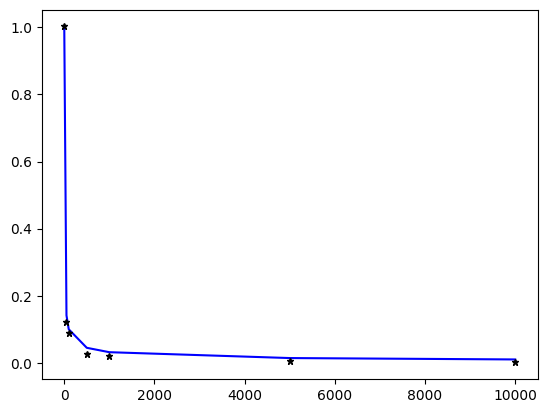

In [6]:
# Can we also confirm that the Høvsøre data follows "the law of large numbers"?

N_H = [1,50,100,500,1000,5000,10000]

U_1 = np.floor(len(U)/N_H[-1]) # How many times does 10,000 fit into the total data length?
U_2 = U[:N_H[-1]*int(U_1)] # We take only the part of the array which can be reshaped into a rectangular array
Stdevs_H = [U_2.reshape((Ni,int(len(U_2)/Ni))).mean(axis=0).std() for Ni in N_H ]
TheoreticalStdevs_H = np.std(U)/np.sqrt(N_H)

plt.plot(N_H,TheoreticalStdevs_H/np.std(U),'-b')
plt.plot(N_H,Stdevs_H/np.std(U),'*k',markersize = 5)
plt.show()

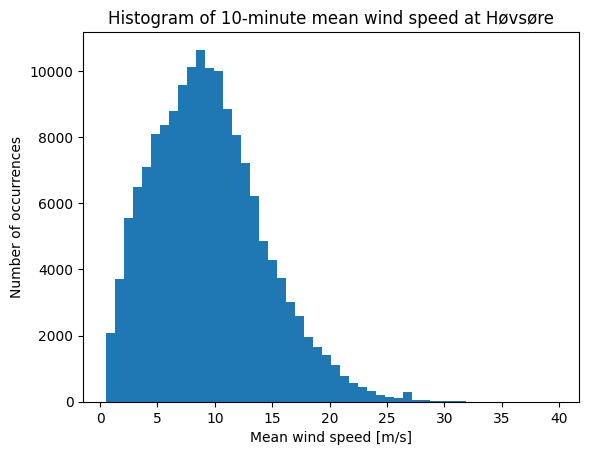

In [7]:
# Histogram of the data
fig1 = plt.figure()
axs1 = plt.gca()
hist1 = axs1.hist(U,50)
plt.xlabel('Mean wind speed [m/s]')
plt.ylabel('Number of occurrences')
plt.title('Histogram of 10-minute mean wind speed at Høvsøre')
plt.show()

In [ ]:
# REPEAT EMPIRICAL PDF COMPUTATION



In [ ]:
# PLOT EMPIRICAL PDF

In [ ]:
# REPEAT EMPIRICAL CDF COMPUTATION

In [8]:
# DISTRIBUTION FITTING USING THE METHOD OF MOMENTS

from scipy.special import gamma
from scipy import optimize

Afunc = lambda k: Umean/gamma(1 + 1/k)
VarFunc = lambda k: (Afunc(k)**2)*(gamma(1 + 2/k) - gamma(1 + 1/k)**2) 
ZeroFunc = lambda k: VarFunc(k) - Uvar

VarOpt = optimize.fsolve(ZeroFunc,2)
k_moments = VarOpt[0]
A_moments = Afunc(k_moments)


In [9]:
print('A:' + str(A_moments))
print('k:' + str(k_moments))

A:10.677843105854317
k:2.0418061403954915


In [ ]:
# DISTRIBUTION FITTING USING MAX-LIKELIHOOD


# Normal distribution fit using the max-likelihood method
norm_likelihood = lambda theta: -np.sum( np.log( stats.norm.pdf(U,loc=theta[0],scale=theta[1]) ) ) # Definition of the negative log-likelihood function
norm_opt = optimize.minimize(norm_likelihood,[10,5]) # Minimization to find the optimal distribution parameters


# INSERT YOUR CODE HERE
# Weibull distribution fit using the max-likelihood method
weibull_likelihood = lambda theta: -np.sum(np.log(stats.weibull_min.pdf(U, c=theta[1], loc=0, scale=theta[0])))
 # Definition of the negative log-likelihood function
weibull_opt = optimize.minimize(weibull_likelihood, [A_moments, k_moments])
# END YOUR CODE HERE

# INSERT YOUR CODE HERE
# Lognormal distribution fit using the max-likelihood method
lognorm_likelihood = lambda theta: -np.sum(np.log(stats.lognorm.pdf(U, s=theta[1], loc=0, scale=np.exp(theta[0]))))
mu_0 = np.log((Umean**2)/np.sqrt(Umean**2 + Uvar)) # Some help to determine the right relation between data stats and LN distribution parameters
sigma_0 = np.log(1 + Uvar/(Umean**2))
thetalog_0 = [mu_0,sigma_0]
lognorm_opt = optimize.minimize(lognorm_likelihood, thetalog_0)
# END YOUR CODE HERE


c:\Users\natal\repos\OceanCourses\.ocean\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2076: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
c:\Users\natal\repos\OceanCourses\.ocean\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2076: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
c:\Users\natal\repos\OceanCourses\.ocean\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2076: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)


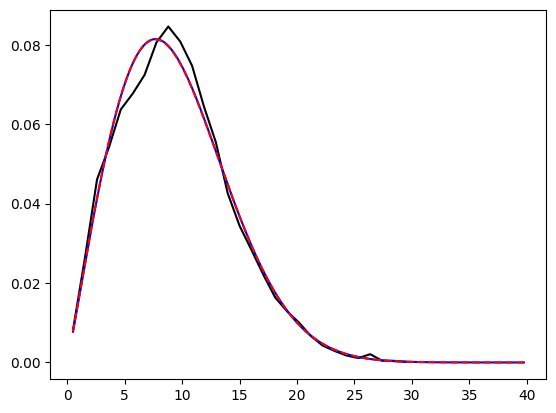

Distribution parameters using the method of moments: A = 10.677843105854317, k = 2.0418061403954915
Distribution parameters using the max-likelihood method: A = 10.67349829583454, k = 2.0378495264053567


In [ ]:
# DO WE GET THE SAME WEIBULL DISTRIBUTION WITH THE TWO METHODS?
U_sort = np.sort(U)
Ubins = np.linspace(0,30,30)
Ubinsc = Ubins[:-1] + np.diff(Ubins)/2 # Find the bin centers for plotting (histogram is based on bin edges!)
Updf = np.histogram(U, bins = Ubins, density = True)[0]

plt.plot(Ubinsc, Updf,'-k')
plt.plot(U_sort, stats.weibull_min.pdf(U_sort,c=k_moments, scale = A_moments),'-b')
plt.plot(U_sort, stats.weibull_min.pdf(U_sort,c=weibull_opt.x[1],scale = weibull_opt.x[0]),'--r')
plt.show()
print('Distribution parameters using the method of moments: A = ' + str(A_moments) + ', k = ' + str(k_moments))
print('Distribution parameters using the max-likelihood method: A = ' + str(weibull_opt.x[0]) + ', k = ' + str(weibull_opt.x[1]))



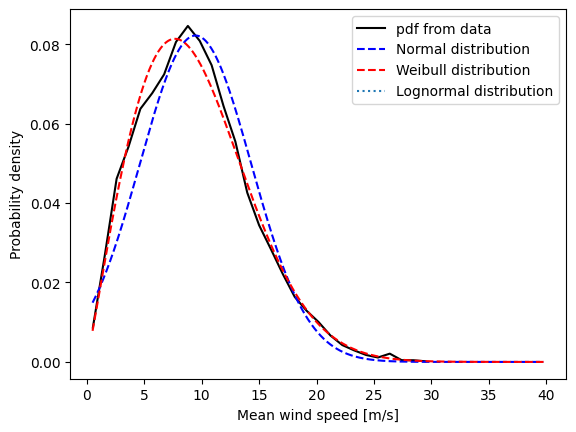

In [12]:
# PLOTTING A COMPARISON BETWEEN DIFFERENT DISTRIBUTIONS

plt.plot(Ubinsc,Updf,'-k')
plt.plot(U_sort,stats.norm.pdf(U_sort,norm_opt.x[0],norm_opt.x[1]),'--b')
plt.plot(U_sort,stats.weibull_min.pdf(U_sort,c=weibull_opt.x[1],scale = weibull_opt.x[0]),'--r')
plt.plot(U_sort,stats.lognorm.pdf(U_sort,s=lognorm_opt.x[1],scale = lognorm_opt.x[0]),':')
plt.xlabel('Mean wind speed [m/s]')
plt.ylabel('Probability density')
plt.legend(['pdf from data','Normal distribution','Weibull distribution','Lognormal distribution'])
plt.show()

# 1.8. How good is my distribution fit?

### Q-Q plots
Q-Q plots are a visual method to check how good a distribution fit is. The "Q" in the name comes from quantiles. A quantile is a point dividing the probability distribution into continuous equal-probability intervals. For a data sample of size $N$, we can thus consider the data points as "quantiles" dividing the distribution into $N+1$ intervals where each interval has probability $1/(N+1)$. Under this assumption, the following is true:

$x = Q(p) = F^{-1}(p)$

In other words, the quantile $x$ should be equivalent to the inverse cdf of the probability distribution. This allows us to check how well a given parametric distribution fits to the data. The Q-Q plot is made with the following steps:

1) Evaluate the empirical cdf of the data sample points, $\hat{F}(\hat{x})$

2) Evaluate the theoretical quantiles of the parametric distribution as $x = F^{-1}\left( \hat{F}(\hat{x}) \right)$

3) Plot $x$ against the sorted data sample $\hat{x}$

The closer the points in the Q-Q plot are to a straight line, the better the distribution fit.

## The concept of statistical tests

Statistical tests come into play when we have a hypothesis and want to test to what extent our data supports it.

The statistical tests typically involve defining a “null” hypothesis - an example of a null hypothesis is the assumption that there is no relationship between the observed phenomena (any relationship has occurred by chance).

Our goal is to find out whether we can __reject__ the null hypothesis

The level of statistical significance of our test is defined by the so-called "$p$-value" which is the probability that the null hypothesis is true. It means that if the $p$-value is below a certain confidence limit $\alpha$, then the null hypothesis can be rejected with the specified level of confidence. 

Common statistical tests include:

- T-test: 
    - Measure whether the averages (expected values) of two populations differ significantly from each other
    - Null hypothesis: the two samples have identical averages
    
- KS-test (Kolmogorov-Smirnov test): 
    - Measure whether two samples belong to the same statistical distribution
    - Null hypothesis: the two samples have the same distribution
    - Can be one-sided (comparison of a single data set to a parametric distribution) or two-sided (comparison of two data sets)
    
- Chi-square test: 
    - measure whether there is agreement between the frequency of observation of two categorical variables. Can be used to test whether an input feature has a statistically significant effect on the frequency of occurrence of output categories
    - Null hypothesis: the two samples have identical averages
- f-test:
    - check whether a certain variable has an effect on the variance of the dependent variable. Can be used to eliminate independent variables which have no effect on the output
    - Null hypothesis: a specific variable has no effect on the explained variance


In [ ]:

# Q-Q plots for different distributions:
Qy_Weibull = U_sort
Qx_Weibull = stats.weibull_min.ppf(F_U,c=weibull_opt.x[1],scale = weibull_opt.x[0])
Qy_Norm = U_sort
Qx_Norm = stats.norm.ppf(F_U,loc=norm_opt.x[0],scale = norm_opt.x[1])
Qy_Lognorm = U_sort
Qx_Lognorm = stats.lognorm.ppf(F_U,s=lognorm_opt.x[1],scale = lognorm_opt.x[0])


fig1,axs1 = plt.subplots(1,3,figsize = (16,5))
axs1[0].plot(Qx_Weibull,Qy_Weibull,'*')
axs1[0].plot((np.min(U), np.max(U)),(np.min(U), np.max(U)),'-k')
axs1[0].set_title('Weibull Q-Q plot')
axs1[0].set_xlabel('$F^{-1}_{Weibull}(F_{empirical}(U))$ [m/s]')
axs1[0].set_ylabel('U [m/s]')

axs1[1].plot(Qx_Norm,Qy_Norm,'*')
axs1[1].plot((np.min(U), np.max(U)),(np.min(U), np.max(U)),'-k')
axs1[1].set_title('Normal Q-Q plot')
axs1[1].set_xlabel('$F^{-1}_{Norm}}(F_{empirical}(U))$ [m/s]')
axs1[1].set_ylabel('U [m/s]')

axs1[2].plot(Qx_Lognorm,Qy_Lognorm,'*')
axs1[2].plot((np.min(U), np.max(U)),(np.min(U), np.max(U)),'-k')
axs1[2].set_title('Lognormal Q-Q plot')
axs1[2].set_xlabel('$F^{-1}_{Lognorm}(F_{empirical}(U))$ [m/s]')
axs1[2].set_ylabel('U [m/s]')

plt.show()


ValueError: 
$F^{-1}_{Norm}}(F_{empirical}(U))$ [m/s]
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

<Figure size 1600x500 with 3 Axes>

In the Kolmogorov-Smirnov (K-S) test, the null hypothesis is that two distributions are the same (e.g. a sample belongs to a specific distribution). The p-value estimates the probability that the null hypothesis is true. A p-value below a specified significance level (for example 0.05) would mean that the null hypothesis is rejected with significant confidence (i.e., the two distributions are not the same).

In [13]:
# One-way K-S test

ksW = stats.kstest(U,'weibull_min', weibull_opt.x)
ksN = stats.kstest(U,'norm', norm_opt.x)
ksLN = stats.kstest(U,'lognorm', lognorm_opt.x)

In [14]:
ksW

KstestResult(statistic=np.float64(0.9080941560917256), pvalue=np.float64(0.0), statistic_location=np.float64(3.2343), statistic_sign=np.int8(-1))

In [15]:
ks1 = stats.kstest(np.random.normal(norm_opt.x[0],norm_opt.x[1],100000),'norm',norm_opt.x)
ks1

KstestResult(statistic=np.float64(0.002092437944270137), pvalue=np.float64(0.77285841447466), statistic_location=np.float64(5.01563553155271), statistic_sign=np.int8(1))

# 1.9. Quiz solution - conceptual example with number of babies
A town is served by two hospitals. In the larger about 45 babies are born each day, in the smaller about 15. For a period of 1 year, each hospital recorded the days on which more than 60 percent of the babies born were boys.

Quiz: which hospital do you think recorded more such days?

    A) The larger hospital
    B) The smaller hospital
    C) About the same (that is, within 5 percent of each other)

In [ ]:
import scipy.stats as stats
prob1 = 1 - stats.binom.cdf(int(0.6*15)-1, 15, 0.52) # Binomial distribution
prob2 = 1 - stats.binom.cdf(int(0.6*45)-1, 45, 0.52) 
print('Smaller hospital: ' + str(prob1))
print('Larger hospital: ' + str(prob2))